# SAM RTN Quantization Analysis

This notebook provides a comprehensive analysis of RTN (Round-to-Nearest) quantization for SAM models, focusing on MSE measurement across attention layers.


In [1]:
# Imports
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import defaultdict
from typing import Union, Tuple, Optional, Callable
from functools import partial

# SAM imports
from segment_anything import build_sam, build_sam_hq, sam_hq_model_registry, SamPredictor
# from train.segment_anything_training.modeling.image_encoder import (
    # Block, Attention, window_unpartition, window_partition
# )

# RTN Quantization imports
import sys
sys.path.append('/u/ctran3/Sam_quantization/RTN_quantization')
from per_tensor_channel_group import W8A8Linear
from utils import replace_linear_with_target_and_quantize


/u/ctran3/Sam_quantization/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
# Utility Functions
def to_numpy(x: torch.Tensor):
    return x.detach().cpu().numpy()

def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    
def show_mask_image(mask, ax, random_color=False, borders=True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2)
    ax.imshow(mask_image)

def plot_mask_comparison(original_result, quantized_result, image_path, image_idx,save_path=None):
    """Plot side-by-side comparison of original and quantized masks"""
    import cv2
    
    # Load the original image
    image = cv2.imread(f'{image_path}/example{image_idx}.png')
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Extract masks and scores
    orig_mask = original_result['masks'][0]
    quant_mask = quantized_result['masks'][0]
    orig_score = original_result['scores'][0]
    quant_score = quantized_result['scores'][0]
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Original image
    axes[0, 0].imshow(image)
    axes[0, 0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')
    
    # Original mask
    axes[0, 1].imshow(image)
    show_mask_image(orig_mask, axes[0, 1], random_color=False, borders=True)
    axes[0, 1].set_title(f'Original Model Mask\nScore: {orig_score:.4f}', fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')
    
    # Quantized mask
    axes[0, 2].imshow(image)
    show_mask_image(quant_mask, axes[0, 2], random_color=False, borders=True)
    axes[0, 2].set_title(f'Quantized Model Mask\nScore: {quant_score:.4f}', fontsize=12, fontweight='bold')
    axes[0, 2].axis('off')
    
    # Mask difference
    mask_diff = np.abs(orig_mask.astype(float) - quant_mask.astype(float))
    axes[1, 0].imshow(mask_diff, cmap='hot')
    axes[1, 0].set_title('Mask Difference\n(Red = High Difference)', fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')
    
    # Score comparison bar chart
    scores = [orig_score, quant_score]
    labels = ['Original', 'Quantized']
    colors = ['skyblue', 'lightcoral']
    bars = axes[1, 1].bar(labels, scores, color=colors, alpha=0.7)
    axes[1, 1].set_title('Score Comparison', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].set_ylim(0, 1)
    
    # Add score values on bars
    for bar, score in zip(bars, scores):
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    
    # Score difference
    score_diff = abs(orig_score - quant_score)
    score_degradation = (score_diff / orig_score) * 100
    
    axes[1, 2].text(0.5, 0.7, f'Score Difference: {score_diff:.6f}', 
                    ha='center', va='center', fontsize=14, fontweight='bold',
                    transform=axes[1, 2].transAxes)
    axes[1, 2].text(0.5, 0.5, f'Degradation: {score_degradation:.2f}%', 
                    ha='center', va='center', fontsize=14, fontweight='bold',
                    transform=axes[1, 2].transAxes)
    axes[1, 2].text(0.5, 0.3, f'Mask MSE: {np.mean(mask_diff):.6f}', 
                    ha='center', va='center', fontsize=14, fontweight='bold',
                    transform=axes[1, 2].transAxes)
    axes[1, 2].set_title('Quantization Impact', fontsize=12, fontweight='bold')
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Mask comparison plot saved to {save_path}")
    
    plt.show()

def plot_individual_masks(original_result, quantized_result, image_path, save_path=None):
    """Plot individual masks separately for detailed analysis"""
    import cv2
    
    # Load the original image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Extract masks and scores
    orig_mask = original_result['masks'][0]
    quant_mask = quantized_result['masks'][0]
    orig_score = original_result['scores'][0]
    quant_score = quantized_result['scores'][0]
    
    # Create figure with 2x2 subplots
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Original mask
    axes[0, 0].imshow(image)
    show_mask_image(orig_mask, axes[0, 0], random_color=False, borders=True)
    axes[0, 0].set_title(f'Original Model Mask\nScore: {orig_score:.4f}', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')
    
    # Quantized mask
    axes[0, 1].imshow(image)
    show_mask_image(quant_mask, axes[0, 1], random_color=False, borders=True)
    axes[0, 1].set_title(f'Quantized Model Mask\nScore: {quant_score:.4f}', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')
    
    # Mask difference
    mask_diff = np.abs(orig_mask.astype(float) - quant_mask.astype(float))
    im = axes[1, 0].imshow(mask_diff, cmap='hot')
    axes[1, 0].set_title('Mask Difference\n(Red = High Difference)', fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')
    plt.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)
    
    # Score comparison
    scores = [orig_score, quant_score]
    labels = ['Original', 'Quantized']
    colors = ['skyblue', 'lightcoral']
    bars = axes[1, 1].bar(labels, scores, color=colors, alpha=0.7)
    axes[1, 1].set_title('Score Comparison', fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].set_ylim(0, 1)
    
    # Add score values on bars
    for bar, score in zip(bars, scores):
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Individual mask plot saved to {save_path}")
    
    plt.show()


In [12]:
# Observer Base Class
class ObserverBase:
    dictionary = {}
    
    def __init__(self, module_list: Tuple):
        self.module_list = module_list
        self.hooks = []

    def register_hooks(self, model: nn.Module, pre_hook: Optional[Callable] = None, post_hook: Optional[Callable] = None):
        for name, module in model.named_modules():
            if post_hook is not None:
                if isinstance(module, self.module_list):
                    self.hooks.append(module.register_forward_hook(partial(post_hook, name=name)))
            if pre_hook is not None:
                if isinstance(module, self.module_list):
                    self.hooks.append(module.register_forward_pre_hook(partial(pre_hook, name=name)))

    def clear_hook(self):
        for hook in self.hooks:
            hook.remove()

    def clear_dict(self):
        ObserverBase.dictionary = {}
    
    def register_energy_hook(self, model: nn.Module):
        """Register energy hooks for the model"""
        self.dictionary['energy'] = defaultdict(list)
        def pre_hook(module, input, name):
            if 'attn' in name and input and len(input) > 0:
                x = input[0]
                if hasattr(x, 'shape') and len(x.shape) >= 2:
                    energy = torch.norm(x, dim=-1).mean().item()
                    self.dictionary['energy'][name].append(energy)
        self.register_hooks(model, pre_hook=pre_hook)

    @torch.inference_mode()
    def inference_image(self, predictor, image_dir: str = './input_imgs', show_image: bool = False, example_idx: int = 1):
        """Run inference on a single image"""
        import cv2
        image = cv2.imread(f'{image_dir}/example{example_idx}.png')
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Configure based on example index
        if example_idx == 0:
            input_box = np.array([[4, 13, 1007, 1023]])
            input_point, input_label = None, None
            hq_token_only = False
        elif example_idx == 1:
            input_box = np.array([[306, 132, 925, 893]])
            input_point, input_label = None, None
            hq_token_only = True
        elif example_idx == 2:
            input_point = np.array([[495, 518], [217, 140]])
            input_label = np.ones(input_point.shape[0])
            input_box = None
            hq_token_only = True
        else:
            input_box = np.array([[306, 132, 925, 893]])
            input_point, input_label = None, None
            hq_token_only = True
        
        if isinstance(predictor, SamPredictor):
            predictor.set_image(image)
            try:
                masks, scores, logits = predictor.predict(
                    point_coords=input_point,
                    point_labels=input_label,
                    box=input_box,
                    multimask_output=False,
                    hq_token_only=hq_token_only,
                )
            except TypeError as e:
                if "hq_token_only" in str(e):
                    masks, scores, logits = predictor.predict(
                        point_coords=input_point,
                        point_labels=input_label,
                        box=input_box,
                        multimask_output=False,
                    )
                else:
                    raise e
        
        if show_image:
            plt.figure(figsize=(10, 10))
            plt.imshow(image)
            if len(masks) > 0:
                show_mask_image(masks[0], plt.gca(), random_color=False)
            if input_box is not None:
                box = input_box[0]
                x0, y0 = box[0], box[1]
                w, h = box[2] - box[0], box[3] - box[1]
                plt.gca().add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))
            if input_point is not None and input_label is not None:
                show_points(input_point, input_label, plt.gca())
            plt.title(f'Example {example_idx} - Score: {scores[0]:.3f}')
            plt.axis('off')
            plt.show()

        return masks, scores, logits


In [13]:
# RTN Quantization System
class SAMQuantizer:
    def __init__(self, n_bits=8, weight_quant="per_channel", act_quant="per_token", quantize_output=False):
        self.n_bits = n_bits
        self.weight_quant = weight_quant
        self.act_quant = act_quant
        self.quantize_output = quantize_output
        self.modules_to_exclude = [
            "pos_embed", "cls_token", "patch_embed", "neck", "fpn", 
            "mask_tokens", "iou_token", "output_upscaling", "output_hypernetworks_mlps",
            "prompt_encoder", "mask_decoder"
        ]
    
    def quantize_model(self, model):
        """Apply RTN quantization to the SAM model"""
        print(f"Quantizing SAM model with {self.n_bits}-bit precision...")
        print(f"Weight quantization: {self.weight_quant}")
        print(f"Activation quantization: {self.act_quant}")
        
        if hasattr(model, 'image_encoder'):
            replace_linear_with_target_and_quantize(
                module=model.image_encoder,
                target_class=W8A8Linear,
                n_bit=self.n_bits,
                module_name_to_exclude=self.modules_to_exclude,
                weight_quant=self.weight_quant,
                act_quant=self.act_quant,
                quantize_output=self.quantize_output
            )
            print("Image encoder quantized successfully!")
        else:
            print("Warning: No image_encoder found in model")
        
        return model
    
    def get_quantized_layers_info(self, model):
        """Get information about quantized layers"""
        quantized_layers = []
        for name, module in model.named_modules():
            if isinstance(module, W8A8Linear):
                quantized_layers.append({
                    'name': name,
                    'in_features': module.in_features,
                    'out_features': module.out_features,
                    'n_bits': module.n_bits,
                    'weight_quant': getattr(module, 'weight_quant_name', 'unknown'),
                    'act_quant': module.act_quant_name,
                    'output_quant': module.output_quant_name
                })
        return quantized_layers


In [ ]:
# Attention Error Analysis System
class AttentionErrorAnalyzer:
    def __init__(self):
        self.original_outputs = {}
        self.quantized_outputs = {}
        self.error_metrics = {}
        self.hooks = []
    
    def register_hooks(self, model, model_type="original"):
        """Register hooks to capture attention outputs"""
        def create_hook(name, outputs_dict):
            def hook(module, input, output):
                if isinstance(output, tuple):
                    outputs_dict[name] = [o.detach().cpu() for o in output]
                else:
                    outputs_dict[name] = output.detach().cpu()
            return hook
        
        for name, module in model.named_modules():
            if 'attn' in name and hasattr(module, 'qkv'):
                hook = module.register_forward_hook(create_hook(name, 
                    self.original_outputs if model_type == "original" else self.quantized_outputs))
                self.hooks.append(hook)
    
    def clear_hooks(self):
        """Remove all registered hooks"""
        for hook in self.hooks:
            hook.remove()
        self.hooks = []
    
    def register_input_quant_hooks(self, model, n_bits=8, top_ratio=0.1, bottom_ratio=0.0, mode='high', margin=0.5):
        """
        Inject forward_pre_hooks on attention modules to quantize only selected input tokens.
        mode: 'high' or 'low' to select high- or low-energy tokens per module input.
        """
        assert mode in ('high', 'low')
        
        def quantize_absmax(x: torch.Tensor, bits: int) -> torch.Tensor:
            if bits >= 16:
                return x
            qmax = 2 ** (bits - 1) - 1
            scale = x.abs().amax(dim=-1, keepdim=True) / qmax + 1e-12
            x_q = torch.clamp(torch.round(x / scale), min=-(qmax + 1), max=qmax)
            return x_q * scale
        
        def compute_energy_tokens(x: torch.Tensor) -> torch.Tensor:
            # Expect x in shape [B, H, W, C] or [B, T, C] or [..., T, C]
            if x.dim() == 4:
                B, H, W, C = x.shape
                x2 = x.reshape(B, H * W, C)
            elif x.dim() == 3:
                x2 = x
            else:
                x2 = x.reshape(-1, x.shape[-2], x.shape[-1])
            x2 = torch.nn.functional.normalize(x2, dim=-1, p=2)
            sim = x2 @ x2.transpose(-1, -2)
            scores = torch.nn.functional.elu(sim - margin).mean(dim=-1)  # [B, T]
            return scores
        
        def make_prehook():
            def pre_hook(module, inputs):
                x = inputs[0]
                if not torch.is_tensor(x):
                    return
                # compute energy and select indices
                with torch.no_grad():
                    if x.dim() == 4:
                        B, H, W, C = x.shape
                        T = H * W
                        x_flat = x.reshape(B, T, C)
                    elif x.dim() == 3:
                        B, T, C = x.shape
                        x_flat = x
                    else:
                        x_flat = x.reshape(-1, x.shape[-2], x.shape[-1])
                        B, T, C = x_flat.shape
                    energies = compute_energy_tokens(x)
                    k = max(1, int((top_ratio if mode == 'high' else bottom_ratio) * T))
                    if mode == 'high':
                        idx = torch.topk(energies, k=k, dim=-1, largest=True).indices
                    else:
                        idx = torch.topk(energies, k=k, dim=-1, largest=False).indices
                    # apply quantization to selected tokens
                    x_mod = x_flat.clone()
                    for b in range(B):
                        rows = idx[b]
                        x_mod[b, rows] = quantize_absmax(x_mod[b, rows], n_bits)
                    # reshape back
                    if x.dim() == 4:
                        x_mod = x_mod.reshape(B, H, W, C)
                    inputs = (x_mod,) + inputs[1:]
                return inputs
            return pre_hook
        
        for name, module in model.named_modules():
            if 'attn' in name and hasattr(module, 'qkv'):
                handle = module.register_forward_pre_hook(make_prehook())
                self.hooks.append(handle)
    
    def clear_outputs(self):
        """Clear stored outputs"""
        self.original_outputs = {}
        self.quantized_outputs = {}
        self.error_metrics = {}
    
    def compute_error_metrics(self):
        """Compute MSE between original and quantized outputs"""
        if not self.original_outputs or not self.quantized_outputs:
            print("Warning: No outputs to compare. Run inference on both models first.")
            return {}
        
        error_metrics = {}
        
        for layer_name in self.original_outputs:
            if layer_name not in self.quantized_outputs:
                print(f"Warning: Layer {layer_name} not found in quantized outputs")
                continue
            
            orig_output = self.original_outputs[layer_name]
            quant_output = self.quantized_outputs[layer_name]
            
            if isinstance(orig_output, list) and isinstance(quant_output, list):
                layer_metrics = {}
                for i, (orig, quant) in enumerate(zip(orig_output, quant_output)):
                    if orig.shape != quant.shape:
                        print(f"Warning: Shape mismatch in {layer_name}[{i}]: {orig.shape} vs {quant.shape}")
                        continue
                    
                    mse = torch.mean((orig - quant) ** 2).item()
                    output_names = ['q', 'k', 'v']
                    output_name = output_names[i] if i < len(output_names) else f'output_{i}'
                    
                    layer_metrics[output_name] = {
                        'mse': mse,
                        'shape': orig.shape
                    }
                
                error_metrics[layer_name] = layer_metrics
            else:
                if orig_output.shape != quant_output.shape:
                    print(f"Warning: Shape mismatch in {layer_name}: {orig_output.shape} vs {quant_output.shape}")
                    continue
                
                mse = torch.mean((orig_output - quant_output) ** 2).item()
                error_metrics[layer_name] = {
                    'single_output': {
                        'mse': mse,
                        'shape': orig_output.shape
                    }
                }
        
        self.error_metrics = error_metrics
        return error_metrics
    
    def compute_selective_token_quant_error(self, n_bits=8, energy_from='q', top_ratio=0.1, bottom_ratio=0.1, margin=0.5):
        """
        Compute MSE when quantizing only high-energy or low-energy tokens.
        - energy_from: 'q' | 'k' | 'v' selects which output to compute energy on
        - ratios are fractions of tokens to quantize
        Returns dict[layer][{'high_only':..., 'low_only':...}] with shapes and counts.
        """
        if not self.original_outputs:
            print("Warning: No outputs captured. Run inference on the original model first.")
            return {}
        
        def quantize_absmax(x: torch.Tensor, bits: int) -> torch.Tensor:
            if bits >= 16:
                return x
            qmax = 2 ** (bits - 1) - 1
            scale = x.abs().amax(dim=-1, keepdim=True) / qmax + 1e-12
            x_q = torch.clamp(torch.round(x / scale), min=-(qmax + 1), max=qmax)
            return x_q * scale
        
        def compute_energy(tokens: torch.Tensor, margin_val: float) -> torch.Tensor:
            # tokens shape [..., T, C]; compute per-token density via normalized dot products
            x = tokens
            if x.dim() < 2:
                return torch.zeros(0, device=x.device)
            x = x.reshape(-1, x.shape[-2], x.shape[-1])
            x = torch.nn.functional.normalize(x, dim=-1, p=2)
            sim = x @ x.transpose(-1, -2)
            scores = torch.nn.functional.elu(sim - margin_val).mean(dim=-1)  # [B*, T]
            return scores
        
        idx_map = {'q': 0, 'k': 1, 'v': 2}
        if energy_from not in idx_map:
            raise ValueError("energy_from must be one of 'q', 'k', 'v'")
        tgt_idx = idx_map[energy_from]
        
        selective_errors = {}
        
        for layer_name, outputs in self.original_outputs.items():
            if not isinstance(outputs, list) or len(outputs) < 3:
                continue
            tgt = outputs[tgt_idx]
            # reshape to [-1, T, C]
            x = tgt
            if x.dim() == 4:
                # assume [B, T, H, C] -> merge heads
                x = x.permute(0, 2, 1, 3).reshape(x.shape[0] * x.shape[2], x.shape[1], x.shape[3])
            elif x.dim() == 3:
                x = x
            else:
                x = x.reshape(-1, x.shape[-2], x.shape[-1])
            
            Bstar, T, C = x.shape
            if T == 0:
                continue
            top_k = max(1, int(top_ratio * T))
            bot_k = max(1, int(bottom_ratio * T))
            
            with torch.no_grad():
                energies = compute_energy(x, margin).to(x.device)  # [B*, T]
                # high energy indices per batch
                high_idx = torch.topk(energies, k=top_k, dim=-1, largest=True).indices  # [B*, K]
                low_idx = torch.topk(energies, k=bot_k, dim=-1, largest=False).indices  # [B*, K]
                
                # Quantize only selected tokens
                def quantize_selected(x_in: torch.Tensor, sel_idx: torch.Tensor) -> torch.Tensor:
                    x_out = x_in.clone()
                    for b in range(x_in.shape[0]):
                        rows = sel_idx[b]
                        x_out[b, rows] = quantize_absmax(x_out[b, rows], n_bits)
                    return x_out
                
                x_high = quantize_selected(x, high_idx)
                x_low = quantize_selected(x, low_idx)
                
                mse_high = torch.mean((x_high - x) ** 2).item()
                mse_low = torch.mean((x_low - x) ** 2).item()
            
            selective_errors[layer_name] = {
                f'{energy_from}_high_only': {
                    'mse': mse_high,
                    'tokens_quantized_per_sample': top_k,
                    'total_tokens': T,
                    'shape': list(tgt.shape)
                },
                f'{energy_from}_low_only': {
                    'mse': mse_low,
                    'tokens_quantized_per_sample': bot_k,
                    'total_tokens': T,
                    'shape': list(tgt.shape)
                }
            }
        
        return selective_errors
    
    def compute_kl_metrics(self, method='token', temperature=1.0, dim=-1, eps=1e-8):
        """
        Compute KL divergence between original and quantized outputs.
        - method='token': apply softmax over the last dimension of tensors and compute KL.
        - method='attn': if q and k are available, build attention matrices softmax(q k^T / temp) and compute KL.
        Returns dict[layer][component] with 'kl' and 'shape'.
        """
        if not self.original_outputs or not self.quantized_outputs:
            print("Warning: No outputs to compare. Run inference on both models first.")
            return {}
        
        def kl_divergence(p, q, reduction='mean'):
            p = torch.clamp(p, min=eps)
            q = torch.clamp(q, min=eps)
            kl = (p * (p.log() - q.log())).sum(dim=-1)
            if reduction == 'mean':
                return kl.mean().item()
            return kl
        
        kl_metrics = {}
        for layer_name in self.original_outputs:
            if layer_name not in self.quantized_outputs:
                continue
            orig = self.original_outputs[layer_name]
            quant = self.quantized_outputs[layer_name]
            layer_metrics = {}
            
            if method == 'attn' and isinstance(orig, list) and isinstance(quant, list) and len(orig) >= 2 and len(quant) >= 2:
                # Expect [q, k, v] or [x, k, v]; try to infer q/k
                o_q, o_k = orig[0], orig[1]
                q_q, q_k = quant[0], quant[1]
                # flatten heads if needed and compute attention probs
                def to_bt_d(x):
                    if x.dim() == 4:
                        # [B, T, H, C] or [B, H, T, C] unknown; try to permute if heads in dim 2
                        B, T, H, C = x.shape
                        return x.permute(0, 2, 1, 3).reshape(B * H, T, C)
                    elif x.dim() == 3:
                        return x
                    else:
                        return x.reshape(-1, x.shape[-2], x.shape[-1])
                o_q_bt, o_k_bt = to_bt_d(o_q), to_bt_d(o_k)
                q_q_bt, q_k_bt = to_bt_d(q_q), to_bt_d(q_k)
                scale = 1.0 / max(temperature, 1e-6)
                o_logits = (o_q_bt @ o_k_bt.transpose(-1, -2)) * scale
                q_logits = (q_q_bt @ q_k_bt.transpose(-1, -2)) * scale
                o_prob = torch.softmax(o_logits, dim=-1)
                q_prob = torch.softmax(q_logits, dim=-1)
                kl_val = kl_divergence(o_prob, q_prob, reduction='mean')
                layer_metrics['attn_prob'] = {'kl': kl_val, 'shape': list(o_prob.shape)}
            
            # Token-wise KL on available tensors
            if isinstance(orig, list) and isinstance(quant, list):
                names = ['q', 'k', 'v']
                for i, (o_t, q_t) in enumerate(zip(orig, quant)):
                    try:
                        p = torch.softmax(o_t, dim=dim)
                        qd = torch.softmax(q_t, dim=dim)
                        layer_metrics[names[i] if i < len(names) else f'out_{i}'] = {
                            'kl': kl_divergence(p, qd, reduction='mean'),
                            'shape': list(o_t.shape)
                        }
                    except Exception:
                        continue
            else:
                try:
                    p = torch.softmax(orig, dim=dim)
                    qd = torch.softmax(quant, dim=dim)
                    layer_metrics['single_output'] = {
                        'kl': kl_divergence(p, qd, reduction='mean'),
                        'shape': list(orig.shape)
                    }
                except Exception:
                    pass
            
            if layer_metrics:
                kl_metrics[layer_name] = layer_metrics
        return kl_metrics
    
    def print_error_summary(self):
        """Print a summary of MSE for each layer"""
        if not self.error_metrics:
            print("No error metrics computed. Run compute_error_metrics() first.")
            return
        
        print("=" * 80)
        print("ATTENTION OUTPUT MSE ANALYSIS")
        print("=" * 80)
        
        for layer_name, metrics in self.error_metrics.items():
            print(f"\\nLayer: {layer_name}")
            print("-" * 40)
            
            for output_name, output_metrics in metrics.items():
                print(f"  {output_name}: MSE = {output_metrics['mse']:.8f}, Shape = {output_metrics['shape']}")
        
        all_mse = []
        for layer_name, metrics in self.error_metrics.items():
            for output_name, output_metrics in metrics.items():
                all_mse.append(output_metrics['mse'])
        
        if all_mse:
            avg_mse = np.mean(all_mse)
            print(f"\\nAverage MSE across all layers: {avg_mse:.8f}")
    
    def plot_error_analysis(self, save_path=None):
        """Create MSE visualization"""
        if not self.error_metrics:
            print("No error metrics computed. Run compute_error_metrics() first.")
            return
        
        layers = []
        mse_values = []
        
        for layer_name, metrics in self.error_metrics.items():
            for output_name, output_metrics in metrics.items():
                layers.append(f"{layer_name}_{output_name}")
                mse_values.append(output_metrics['mse'])
        
        plt.figure(figsize=(12, 6))
        bars = plt.bar(range(len(layers)), mse_values, color='skyblue', alpha=0.7)
        plt.title('Attention Output MSE by Layer', fontsize=14)
        plt.xlabel('Layer and Output Type', fontsize=12)
        plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
        plt.yscale('log')
        
        for i, (bar, mse) in enumerate(zip(bars, mse_values)):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1, 
                    f'{mse:.2e}', ha='center', va='bottom', fontsize=8, rotation=45)
        
        plt.xticks(range(len(layers)), layers, rotation=45, ha='right')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"MSE analysis plot saved to {save_path}")
        
        plt.show()


In [ ]:
# Main Analysis Pipeline
class SAMQuantizationAnalyzer:
    def __init__(self, checkpoint_path, model_type='vit_l', device='cuda'):
        self.checkpoint_path = checkpoint_path
        self.model_type = model_type
        self.device = device
        self.original_model = None
        self.quantized_model = None
        self.quantizer = None
        self.error_analyzer = AttentionErrorAnalyzer()
        
    def load_models(self):
        """Load both original and quantized models"""
        print("Loading original SAM model...")
        self.original_model = sam_hq_model_registry[self.model_type](checkpoint=self.checkpoint_path).to('cuda')
        self.original_model.eval()
        
        print("Loading quantized SAM model...")
        self.quantized_model = sam_hq_model_registry[self.model_type](checkpoint=self.checkpoint_path).to('cuda')
        self.quantized_model.eval()
        
        print("Models loaded successfully!")
        
    def quantize_model(self, n_bits=8, weight_quant="per_channel", act_quant="per_token", quantize_output=False):
        """Quantize the model with specified parameters"""
        self.quantizer = SAMQuantizer(
            n_bits=n_bits,
            weight_quant=weight_quant,
            act_quant=act_quant,
            quantize_output=quantize_output
        )
        
        self.quantized_model = self.quantizer.quantize_model(self.quantized_model)
        
        quantized_layers = self.quantizer.get_quantized_layers_info(self.quantized_model)
        print(f"\\nQuantized {len(quantized_layers)} layers:")
        for layer_info in quantized_layers:
            print(f"  {layer_info['name']}: {layer_info['in_features']} -> {layer_info['out_features']} "
                  f"({layer_info['n_bits']}-bit, {layer_info['weight_quant']}/{layer_info['act_quant']})")
        
        return self.quantized_model
    
    def run_comparison_analysis(self, image_path, example_idx=1, plot_masks=True, save_plots=False, selective_bits=None, top_ratio=0.1, bottom_ratio=0.1, energy_from='q'):
        """Run inference on both models and analyze attention output errors.
        If selective_bits is provided, also compute errors for quantizing only top/bottom energy tokens.
        """
        print(f"Running comparison analysis on image: {image_path}")
        
        self.error_analyzer.clear_outputs()
        self.error_analyzer.register_hooks(self.original_model, "original")
        self.error_analyzer.register_hooks(self.quantized_model, "quantized")
        
        observer_orig = ObserverBase(module_list=(nn.Linear,))
        observer_quant = ObserverBase(module_list=(nn.Linear,))
        
        print("Running inference on original model...")
        predictor_orig = SamPredictor(self.original_model)
        observer_orig.register_energy_hook(predictor_orig.model)
        masks_orig, scores_orig, logits_orig = observer_orig.inference_image(
            predictor_orig, image_dir=image_path, show_image=False, example_idx=example_idx
        )
        
        print("Running inference on quantized model...")
        predictor_quant = SamPredictor(self.quantized_model)
        observer_quant.register_energy_hook(predictor_quant.model)
        masks_quant, scores_quant, logits_quant = observer_quant.inference_image(
            predictor_quant, image_dir=image_path, show_image=False, example_idx=example_idx
        )
        
        print("Computing error metrics...")
        error_metrics = self.error_analyzer.compute_error_metrics()
        
        selective_errors = None
        if selective_bits is not None:
            print(f"Computing selective token quantization errors: bits={selective_bits}, energy_from={energy_from}, top={top_ratio}, bottom={bottom_ratio}")
            selective_errors = self.error_analyzer.compute_selective_token_quant_error(
                n_bits=selective_bits,
                energy_from=energy_from,
                top_ratio=top_ratio,
                bottom_ratio=bottom_ratio
            )
        
        self.error_analyzer.print_error_summary()
        self.error_analyzer.plot_error_analysis()
        
        # Create result dictionary
        result = {
            'original': {'masks': masks_orig, 'scores': scores_orig, 'logits': logits_orig},
            'quantized': {'masks': masks_quant, 'scores': scores_quant, 'logits': logits_quant},
            'error_metrics': error_metrics,
            'selective_errors': selective_errors
        }
        
        # Plot masks if requested
        if plot_masks:
            print("\\n" + "="*50)
            print("MASK VISUALIZATION")
            print("="*50)
            
            # Plot comprehensive comparison
            plot_mask_comparison(
                result['original'], 
                result['quantized'], 
                image_path,
                example_idx,
                save_path=f'mask_comparison_{self.quantizer.n_bits}bit.png' if save_plots else None
            )
            
            # Plot individual masks
            # plot_individual_masks(
            #     result['original'], 
            #     result['quantized'], 
            #     image_path,
            #     example_idx,
            #     save_path=f'individual_masks_{self.quantizer.n_bits}bit.png' if save_plots else None
            # )
        
        print("\\n" + "="*50)
        print("FINAL OUTPUT COMPARISON")
        print("="*50)
        print(f"Original model - Score: {scores_orig[0]:.4f}, Mask shape: {masks_orig[0].shape}")
        print(f"Quantized model - Score: {scores_quant[0]:.4f}, Mask shape: {masks_quant[0].shape}")
        
        if masks_orig[0].shape == masks_quant[0].shape:
            mask_error = np.mean((masks_orig[0].astype(float) - masks_quant[0].astype(float)) ** 2)
            print(f"Mask MSE: {mask_error:.6f}")
        
        score_error = abs(scores_orig[0] - scores_quant[0])
        print(f"Score difference: {score_error:.6f}")
        
        if selective_errors:
            print("\n" + "="*50)
            print("SELECTIVE TOKEN QUANTIZATION ERRORS")
            print("="*50)
            for layer_name, metrics in selective_errors.items():
                for k, v in metrics.items():
                    print(f"{layer_name} - {k}: MSE={v['mse']:.6e} (quantized {v['tokens_quantized_per_sample']}/{v['total_tokens']} tokens per sample)")
        
        return result
    
    def run_input_quant_error_analysis(self, image_path, example_idx=1, bits=8, mode='high', top_ratio=0.1, bottom_ratio=0.1, margin=0.5):
        import cv2
        """
        Quantize only the attention inputs (tokens) according to energy and measure attention output error.
        - mode: 'high' or 'low' for selective token quantization by energy.
        Returns dict with per-layer q/k/v MSE under selective input quant.
        """
        assert mode in ('high', 'low')
        
        # Baseline: capture original outputs
        self.error_analyzer.clear_outputs()
        self.error_analyzer.clear_hooks()
        self.error_analyzer.register_hooks(self.original_model, "original")
        predictor = SamPredictor(self.original_model)
        _ = predictor.set_image(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
        observer = ObserverBase(module_list=(nn.Linear,))
        observer.register_energy_hook(predictor.model)
        _ = observer.inference_image(predictor, image_dir=image_path, show_image=False, example_idx=example_idx)
        
        # Input-quantized pass: attach pre-hooks and capture outputs
        self.error_analyzer.register_input_quant_hooks(self.original_model, n_bits=bits, top_ratio=top_ratio, bottom_ratio=bottom_ratio, mode=mode, margin=margin)
        self.error_analyzer.register_hooks(self.original_model, "quantized")
        predictor2 = SamPredictor(self.original_model)
        _ = predictor2.set_image(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
        observer2 = ObserverBase(module_list=(nn.Linear,))
        observer2.register_energy_hook(predictor2.model)
        _ = observer2.inference_image(predictor2, image_dir=image_path, show_image=False, example_idx=example_idx)
        
        # Compute errors between baseline and input-quantized outputs
        errors = self.error_analyzer.compute_error_metrics()
        # Clean pre-hooks to avoid affecting later runs
        self.error_analyzer.clear_hooks()
        return errors
    
    def cleanup(self):
        """Clean up hooks and free memory"""
        self.error_analyzer.clear_hooks()
        self.error_analyzer.clear_outputs()
        print("Cleanup completed.")


In [22]:
# Test Functions
def test_quantization(n_bits=4, example_idx=0):
    """Test quantization with specified bit precision"""
    
    checkpoint_path = '/u/ctran3/Sam_quantization/pretrained_checkpoint/sam_hq_vit_l.pth'
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    print(f"Testing {n_bits}-bit RTN Quantization for SAM")
    print("=" * 50)
    
    analyzer = SAMQuantizationAnalyzer(
        checkpoint_path=checkpoint_path,
        model_type='vit_l',
        device=device
    )
    
    analyzer.load_models()
    analyzer.quantize_model(
        n_bits=n_bits, 
        weight_quant="per_channel", 
        act_quant="per_token", 
        quantize_output=False
    )
    
    result = analyzer.run_comparison_analysis('./input_imgs/', example_idx=example_idx   )
    
    # Detailed results
    print("\\n" + "="*60)
    print(f"{n_bits}-BIT QUANTIZATION RESULTS")
    print("="*60)
    
    orig_score = result['original']['scores'][0]
    quant_score = result['quantized']['scores'][0]
    score_diff = abs(orig_score - quant_score)
    
    print(f"Original model score: {orig_score:.6f}")
    print(f"Quantized model score: {quant_score:.6f}")
    print(f"Score difference: {score_diff:.6f}")
    print(f"Score degradation: {(score_diff/orig_score)*100:.2f}%")
    
    if 'error_metrics' in result and result['error_metrics']:
        all_mse = []
        layer_count = 0
        
        print(f"\\nLayer-wise MSE Analysis:")
        print("-" * 40)
        
        for layer_name, layer_metrics in result['error_metrics'].items():
            layer_count += 1
            layer_mse = []
            
            for output_name, output_metrics in layer_metrics.items():
                mse = output_metrics['mse']
                layer_mse.append(mse)
                all_mse.append(mse)
            
            avg_layer_mse = np.mean(layer_mse)
            print(f"Layer {layer_count:2d} ({layer_name}): MSE = {avg_layer_mse:.8f}")
        
        if all_mse:
            avg_mse = np.mean(all_mse)
            max_mse = np.max(all_mse)
            min_mse = np.min(all_mse)
            std_mse = np.std(all_mse)
            
            print(f"\\nOverall MSE Statistics:")
            print(f"  Average MSE: {avg_mse:.8f}")
            print(f"  Max MSE:     {max_mse:.8f}")
            print(f"  Min MSE:     {min_mse:.8f}")
            print(f"  Std MSE:     {std_mse:.8f}")
            print(f"  Total layers analyzed: {layer_count}")
    
    analyzer.cleanup()
    print(f"\\n{n_bits}-bit quantization test completed!")
    return result

def compare_quantization_levels(bit_configs=[8, 4, 2], example_idx=0):
    """Compare different quantization levels"""
    
    results = {}
    
    for n_bits in bit_configs:
        print(f"\\n{'='*60}")
        print(f"Testing {n_bits}-bit quantization")
        print(f"{'='*60}")
        
        result = test_quantization(n_bits, example_idx=example_idx)
        results[n_bits] = result
    
    # Summary comparison
    print(f"\\n{'='*80}")
    print("QUANTIZATION COMPARISON SUMMARY")
    print(f"{'='*80}")
    
    for n_bits, result in results.items():
        orig_score = result['original']['scores'][0]
        quant_score = result['quantized']['scores'][0]
        score_diff = abs(orig_score - quant_score)
        
        if 'error_metrics' in result and result['error_metrics']:
            all_mse = []
            for layer_name, layer_metrics in result['error_metrics'].items():
                for output_name, output_metrics in layer_metrics.items():
                    all_mse.append(output_metrics['mse'])
            avg_mse = np.mean(all_mse) if all_mse else 0
        else:
            avg_mse = 0
        
        print(f"{n_bits}-bit: Score diff = {score_diff:.6f}, Avg MSE = {avg_mse:.8f}")
    
    return results


\n============================================================
Testing 8-bit quantization
Testing 8-bit RTN Quantization for SAM
Loading original SAM model...


<All keys matched successfully>
Loading quantized SAM model...
<All keys matched successfully>
Models loaded successfully!
Quantizing SAM model with 8-bit precision...
Weight quantization: per_channel
Activation quantization: per_token
Image encoder quantized successfully!
\nQuantized 96 layers:
  image_encoder.blocks.0.attn.qkv: 1024 -> 3072 (8-bit, per_channel/per_token)
  image_encoder.blocks.0.attn.proj: 1024 -> 1024 (8-bit, per_channel/per_token)
  image_encoder.blocks.0.mlp.lin1: 1024 -> 4096 (8-bit, per_channel/per_token)
  image_encoder.blocks.0.mlp.lin2: 4096 -> 1024 (8-bit, per_channel/per_token)
  image_encoder.blocks.1.attn.qkv: 1024 -> 3072 (8-bit, per_channel/per_token)
  image_encoder.blocks.1.attn.proj: 1024 -> 1024 (8-bit, per_channel/per_token)
  image_encoder.blocks.1.mlp.lin1: 1024 -> 4096 (8-bit, per_channel/per_token)
  image_encoder.blocks.1.mlp.lin2: 4096 -> 1024 (8-bit, per_channel/per_token)
  image_encoder.blocks.2.attn.qkv: 1024 -> 3072 (8-bit, per_channel/p

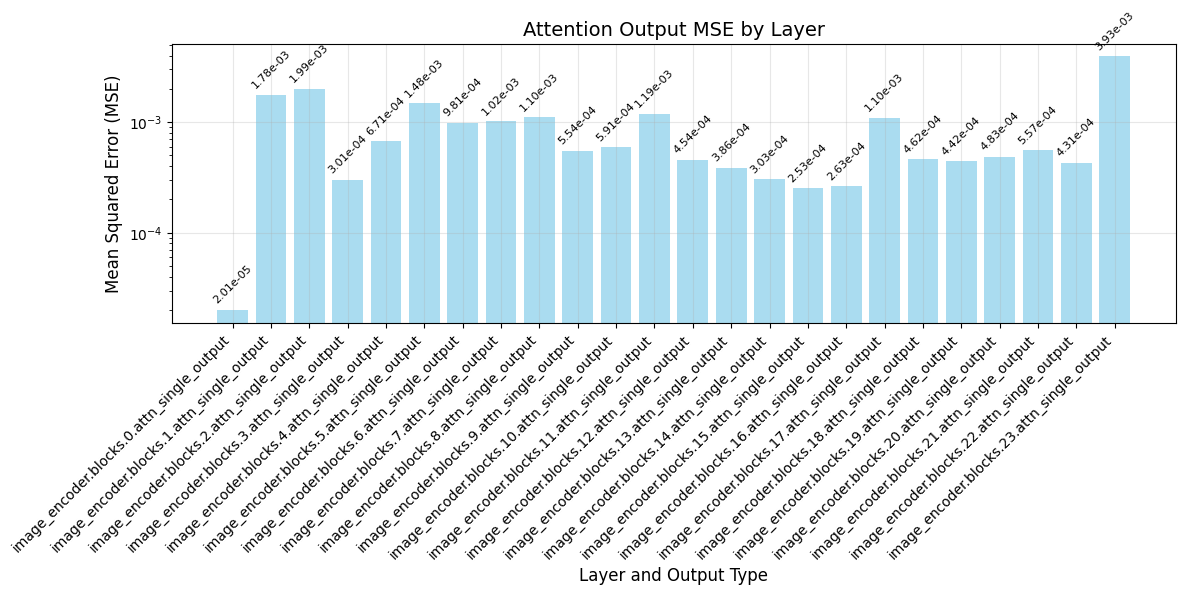

\n==================================================
MASK VISUALIZATION


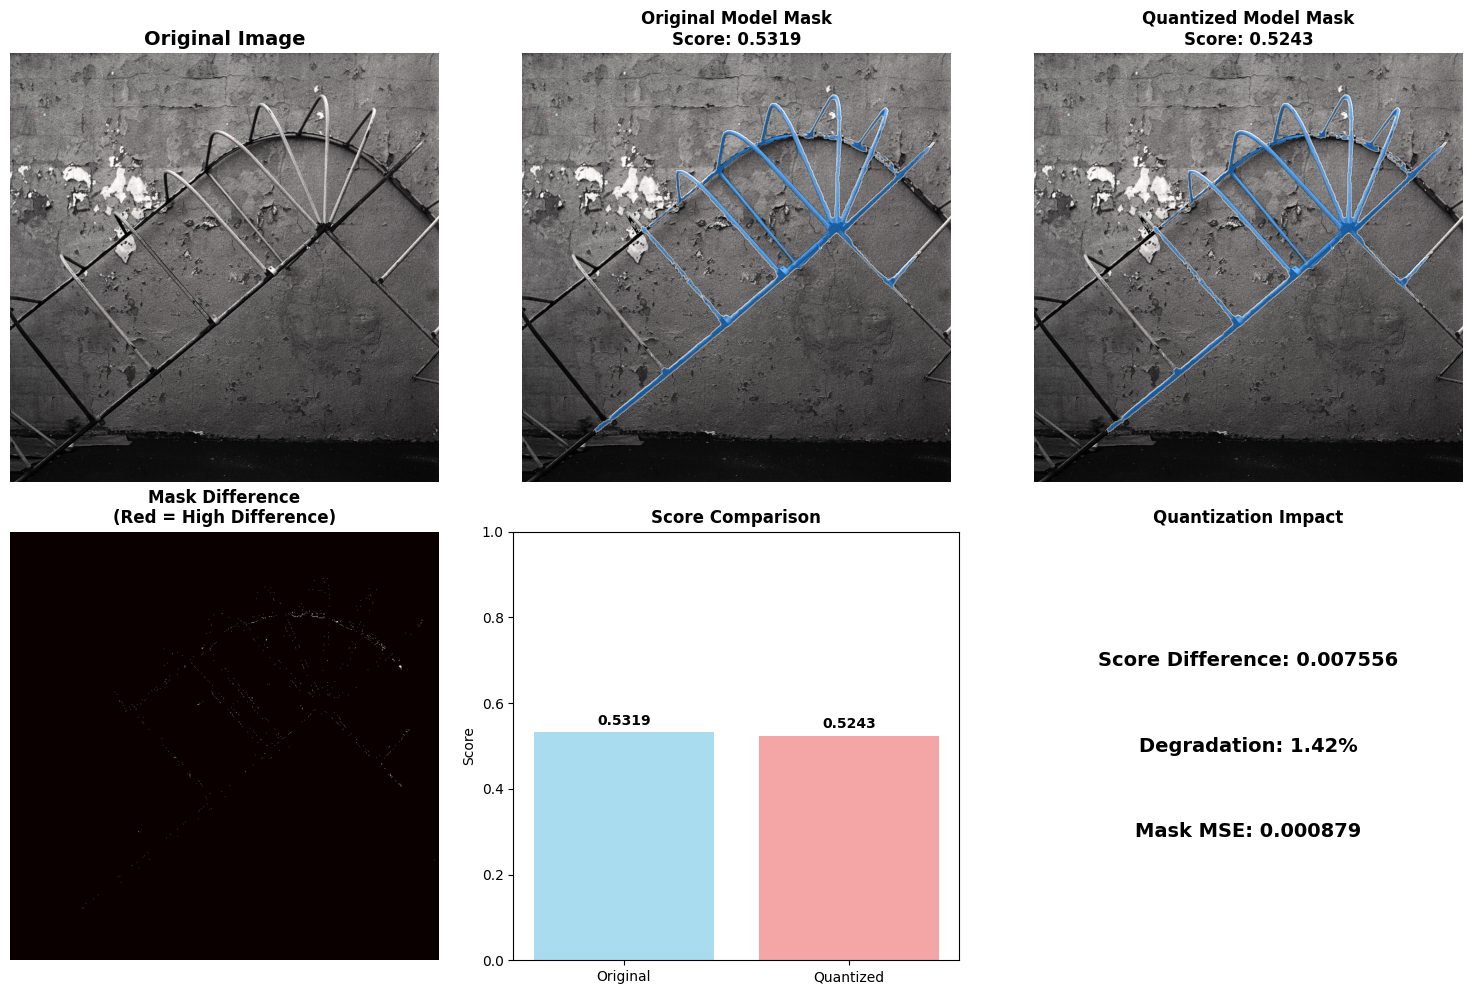

\n==================================================
FINAL OUTPUT COMPARISON
Original model - Score: 0.5319, Mask shape: (1024, 1024)
Quantized model - Score: 0.5243, Mask shape: (1024, 1024)
Mask MSE: 0.000879
Score difference: 0.007556
\n============================================================
8-BIT QUANTIZATION RESULTS
Original model score: 0.531891
Quantized model score: 0.524335
Score difference: 0.007556
Score degradation: 1.42%
\nLayer-wise MSE Analysis:
----------------------------------------
Layer  1 (image_encoder.blocks.0.attn): MSE = 0.00002006
Layer  2 (image_encoder.blocks.1.attn): MSE = 0.00177821
Layer  3 (image_encoder.blocks.2.attn): MSE = 0.00199353
Layer  4 (image_encoder.blocks.3.attn): MSE = 0.00030051
Layer  5 (image_encoder.blocks.4.attn): MSE = 0.00067122
Layer  6 (image_encoder.blocks.5.attn): MSE = 0.00147667
Layer  7 (image_encoder.blocks.6.attn): MSE = 0.00098064
Layer  8 (image_encoder.blocks.7.attn): MSE = 0.00101991
Layer  9 (image_encoder.blocks.8.

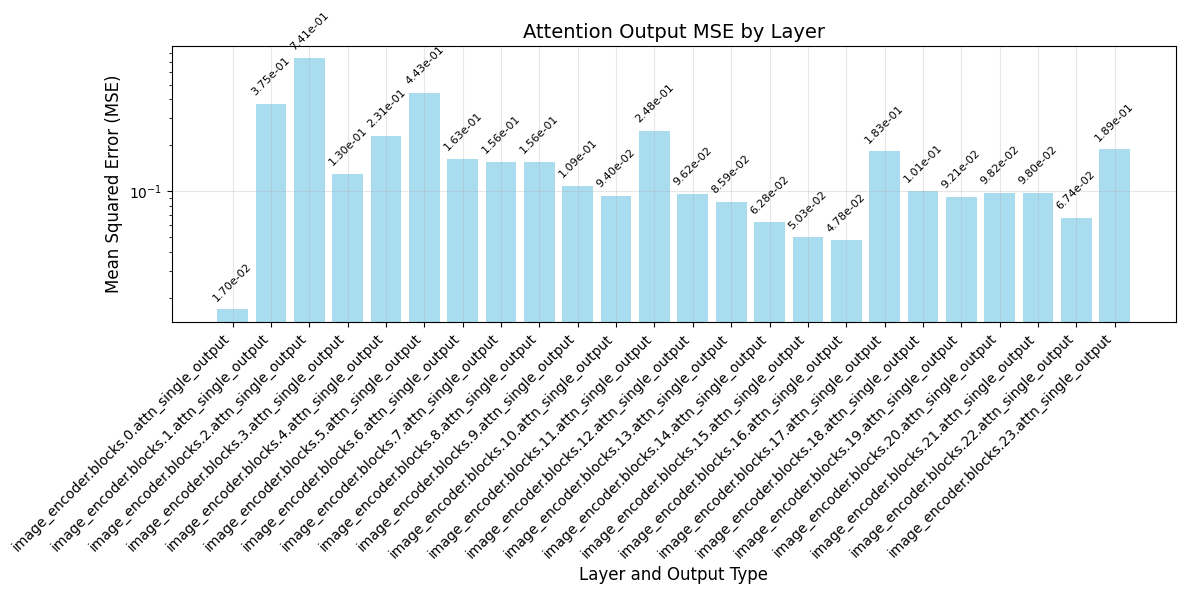

\n==================================================
MASK VISUALIZATION


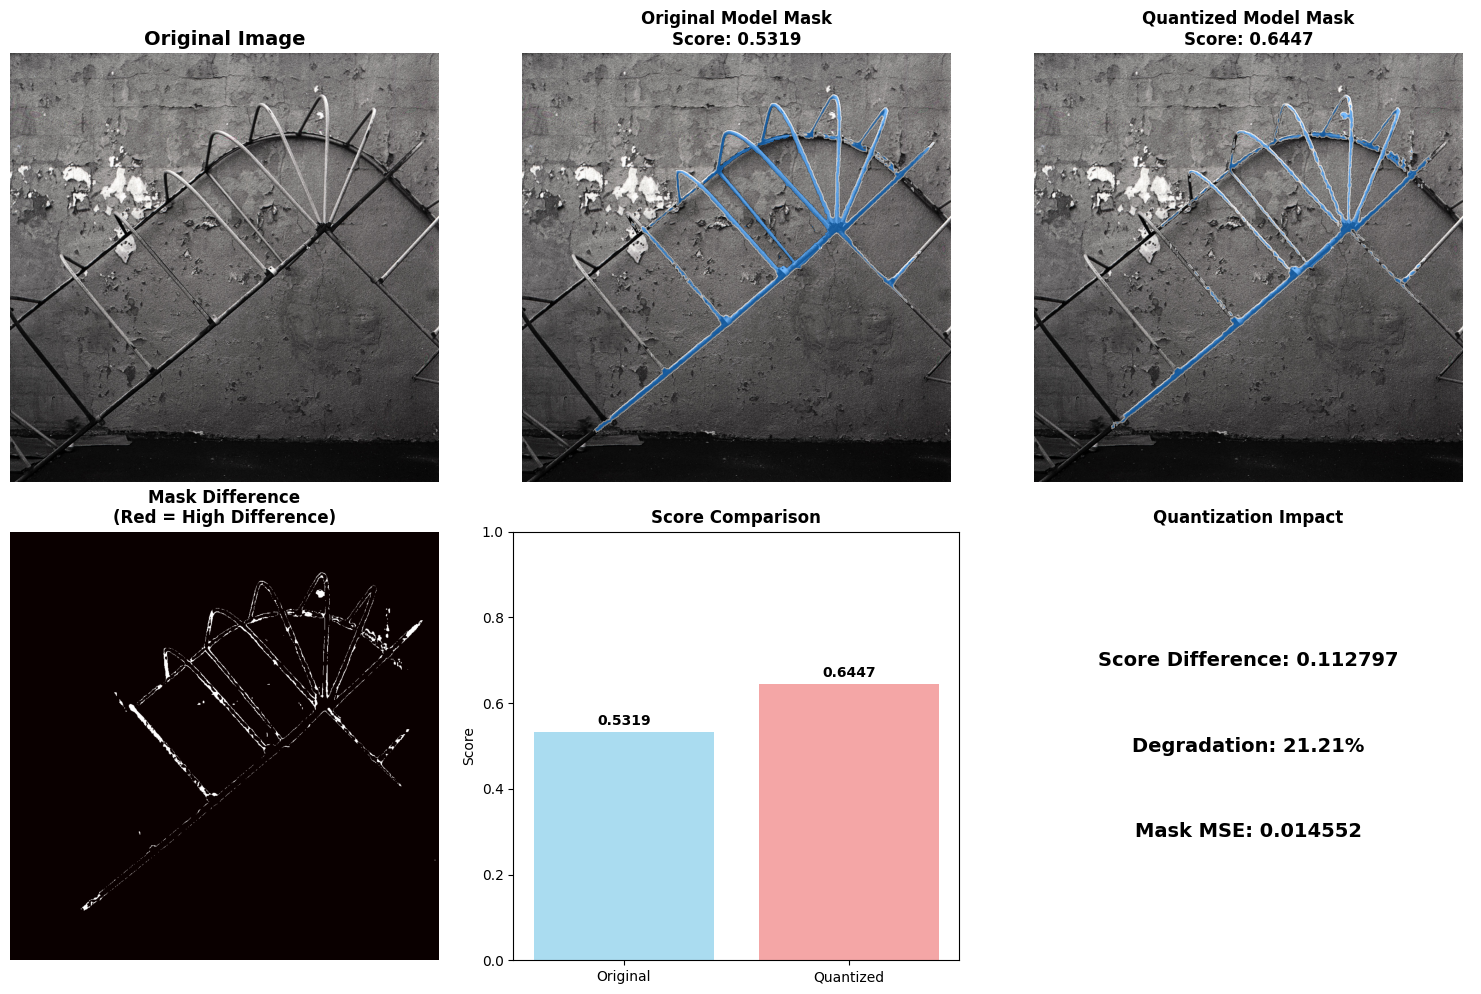

\n==================================================
FINAL OUTPUT COMPARISON
Original model - Score: 0.5319, Mask shape: (1024, 1024)
Quantized model - Score: 0.6447, Mask shape: (1024, 1024)
Mask MSE: 0.014552
Score difference: 0.112797
\n============================================================
4-BIT QUANTIZATION RESULTS
Original model score: 0.531891
Quantized model score: 0.644689
Score difference: 0.112797
Score degradation: 21.21%
\nLayer-wise MSE Analysis:
----------------------------------------
Layer  1 (image_encoder.blocks.0.attn): MSE = 0.01701707
Layer  2 (image_encoder.blocks.1.attn): MSE = 0.37543711
Layer  3 (image_encoder.blocks.2.attn): MSE = 0.74125159
Layer  4 (image_encoder.blocks.3.attn): MSE = 0.13014969
Layer  5 (image_encoder.blocks.4.attn): MSE = 0.23063041
Layer  6 (image_encoder.blocks.5.attn): MSE = 0.44273591
Layer  7 (image_encoder.blocks.6.attn): MSE = 0.16312927
Layer  8 (image_encoder.blocks.7.attn): MSE = 0.15643664
Layer  9 (image_encoder.blocks.8

In [24]:
# Compare different quantization levels
comparison_results = compare_quantization_levels([8, 4], example_idx=3)
